In [39]:
import control as ct 
import matplotlib.pyplot as plt
import numpy as np 
from control import TransferFunction as TF

In [3]:
s = TF.s

In [8]:
b, ζ, ωₙ  = 10, 0.707, 4.0 
P = lambda s:  1 / (s*(s+b)*(s + 2*ζ*ωₙ))
print(P(s))

<TransferFunction>: sys[31]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              1
  -------------------------
  s^3 + 15.66 s^2 + 56.56 s


In [9]:
def feedback_pid(s,P, pid_params):
    Kp, Ki, Kd = pid_params
    C = lambda s: Kp + Ki/s + Kd*s
    L = C(s)*P(s)
    return L/(1+L)

In [44]:
def pid_controller(s,Kp, Ki, Kd):
    return Kp + Ki/s + Kd*s

In [45]:
Ku = float(np.prod(P(s).den[0][0][:-1]))
kp = 0.42*Ku
Ki = 0
Kd = 0
T = ct.feedback(P(s)*pid_controller(s,kp,Ki,Kd),1)
print(T)

<TransferFunction>: sys[390]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                371.9
  ---------------------------------
  s^3 + 15.66 s^2 + 56.56 s + 371.9


Text(0, 0.5, 'Settling Time (s)')

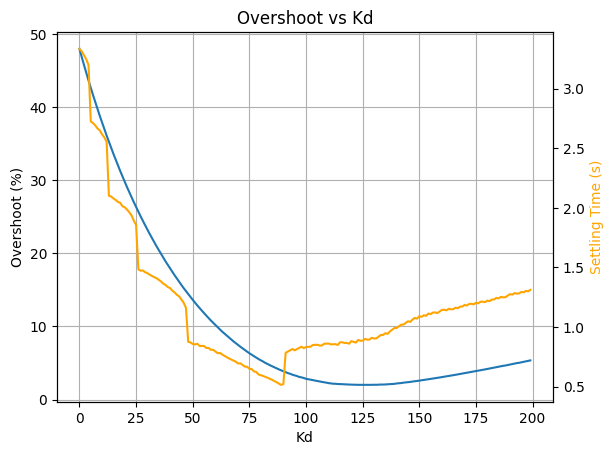

In [50]:
OP = []
Ts = []
for Kd in np.arange(0, 200, 1.0):
    T = ct.feedback(P(s)*pid_controller(s,kp,Ki,Kd),1)
    res = ct.step_info(T)
    OP.append(res['Overshoot'])
    Ts.append(res['SettlingTime'])

plt.plot(np.arange(0, 200, 1.0), OP)
plt.xlabel('Kd')
plt.ylabel('Overshoot (%)')
plt.title('Overshoot vs Kd')
plt.grid()
ax = plt.gca()
ax1 = ax.twinx()
ax1.plot(np.arange(0, 200, 1.0), Ts, color='orange')
ax1.set_ylabel('Settling Time (s)', color='orange')


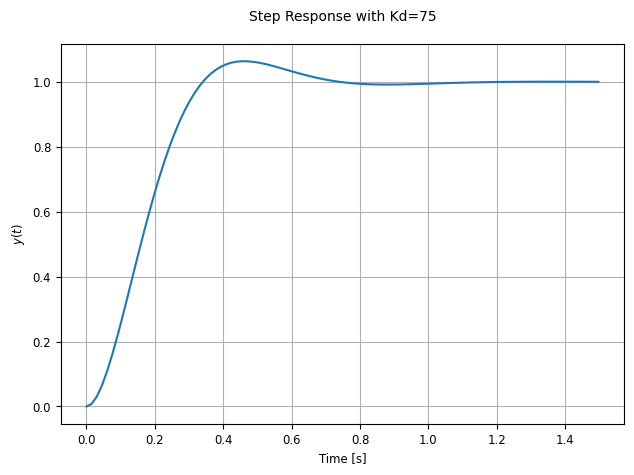

In [56]:
T = ct.feedback(P(s)*pid_controller(s,kp,Ki,75),1)
T.step_response().plot(title='Step Response with Kd=75',label=f'Kd={Kd}')
plt.ylabel(r'$y(t)$')
plt.grid()

In [77]:
def denom(T):
    den = T.den[0][0]
    monomes = [s**k for k in range(den.size,0,-1)]
    denom = TF([0],[1])
    for c, monome in zip(den, monomes):
        denom += c* monome
    return denom

print(denom(P(s)))
    

<TransferFunction>: sys[16796]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  s^4 + 15.66 s^3 + 56.56 s^2
  ---------------------------
               1


In [82]:
kd = 0
P2 = lambda s: 1/(denom(P(s)) + kd*s**2 + kp*s)
print(P2(s))

<TransferFunction>: sys[16980]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                    1
  -------------------------------------
  s^4 + 15.66 s^3 + 56.56 s^2 + 371.9 s


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


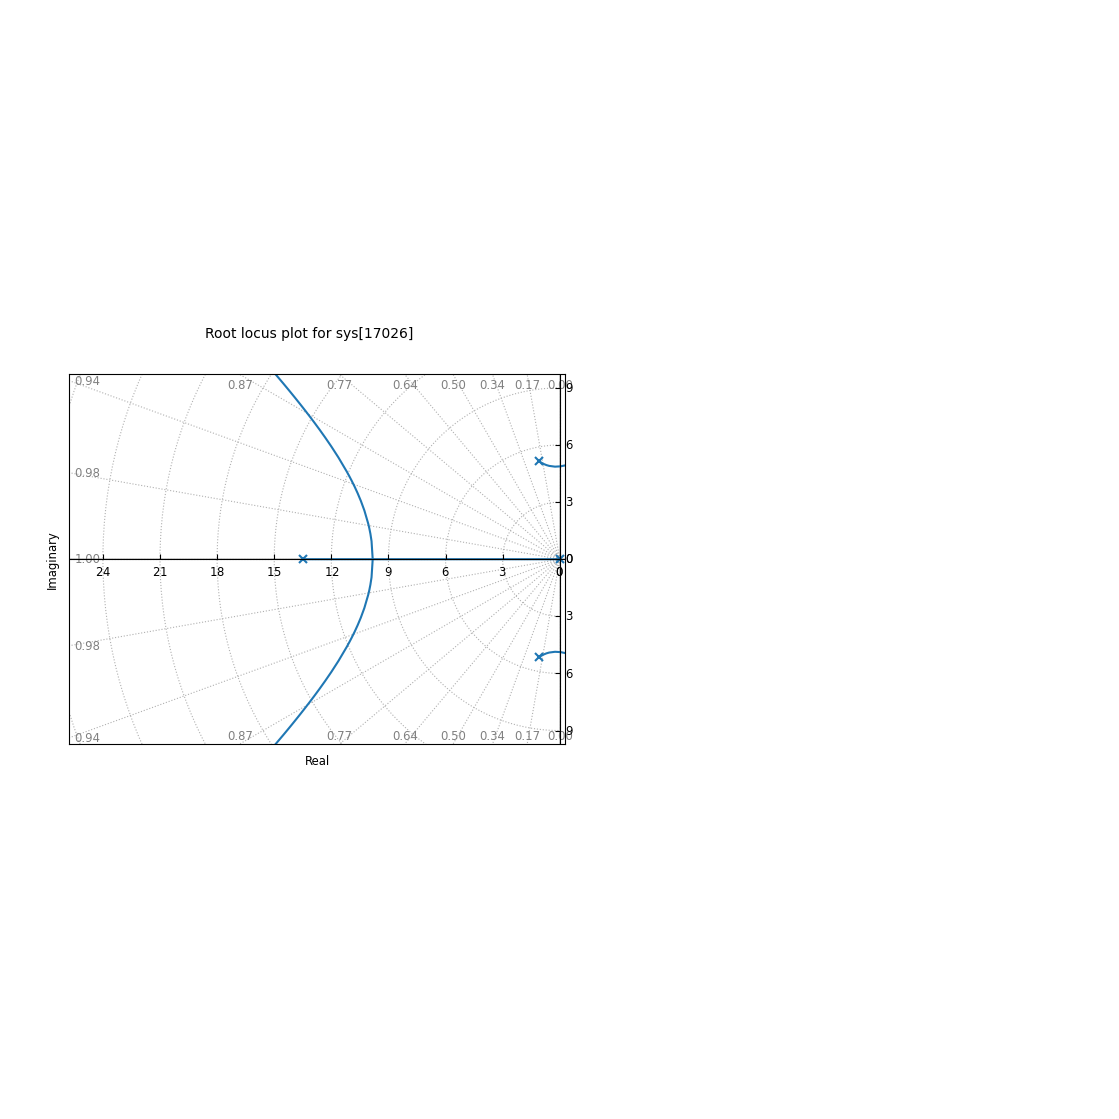

In [83]:
ct.root_locus_plot(P2(s))

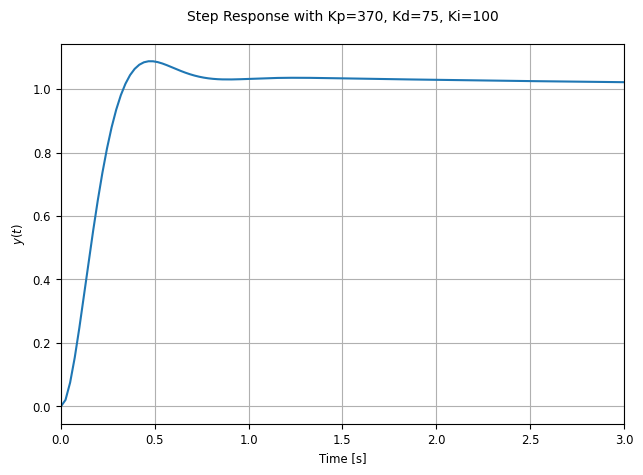

In [85]:
Kp = 370
Kd = 75
Ki = 100
T = ct.feedback(P(s) * pid_controller(s, Kp, Ki, Kd), 1)
T.step_response().plot(title='Step Response with Kp=370, Kd=75, Ki=100')
plt.ylabel(r'$y(t)$')
plt.xlim(0,3)
plt.grid()